In [8]:
import numpy as np
import matplotlib.pyplot as plt


In [9]:
np.random.seed(42)

a = 9
b = 6

n_points = 30 + a
rotation_angle = np.deg2rad(15 * b)
noise_std = 0.01 * a

# Class 0 (Fail)
class0 = np.random.randn(n_points, 2) + np.array([1, 1])

# Class 1 (Pass)
class1 = np.random.randn(n_points, 2) + np.array([4, 4])

R = np.array([
    [np.cos(rotation_angle), -np.sin(rotation_angle)],
    [np.sin(rotation_angle),  np.cos(rotation_angle)]
])

class1 = class1 @ R.T

class0 += np.random.normal(0, noise_std, class0.shape)
class1 += np.random.normal(0, noise_std, class1.shape)

X = np.vstack((class0, class1))
y = np.hstack((np.zeros(n_points), np.ones(n_points)))


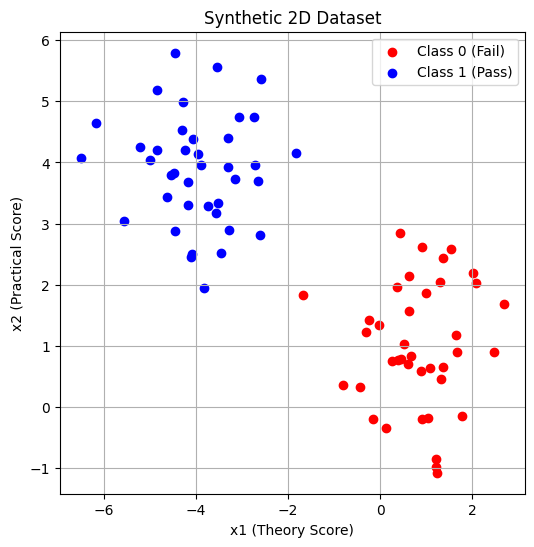

In [10]:
plt.figure(figsize=(6,6))
plt.scatter(class0[:,0], class0[:,1], color='red', label='Class 0 (Fail)')
plt.scatter(class1[:,0], class1[:,1], color='blue', label='Class 1 (Pass)')
plt.xlabel("x1 (Theory Score)")
plt.ylabel("x2 (Practical Score)")
plt.title("Synthetic 2D Dataset")
plt.legend()
plt.grid(True)
plt.show()


In [11]:
X_bias = np.c_[np.ones(X.shape[0]), X]

weights = np.zeros(X_bias.shape[1])
lr = 0.01
epochs = 50

for epoch in range(epochs):
    for i in range(len(X_bias)):
        linear_output = np.dot(X_bias[i], weights)
        y_pred = 1 if linear_output >= 0 else 0
        weights += lr * (y[i] - y_pred) * X_bias[i]


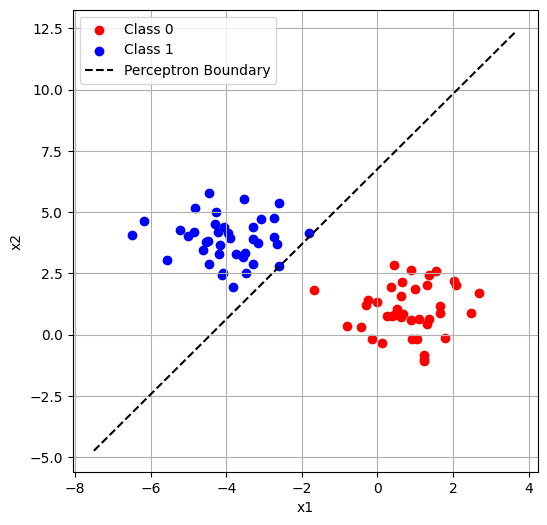

In [12]:
x_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
y_vals = -(weights[0] + weights[1]*x_vals) / weights[2]

plt.figure(figsize=(6,6))
plt.scatter(class0[:,0], class0[:,1], color='red', label='Class 0')
plt.scatter(class1[:,0], class1[:,1], color='blue', label='Class 1')
plt.plot(x_vals, y_vals, 'k--', label='Perceptron Boundary')
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()


In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)

w0 = model.intercept_[0]
w1, w2 = model.coef_[0]

y_vals_lr = -(w0 + w1*x_vals) / w2


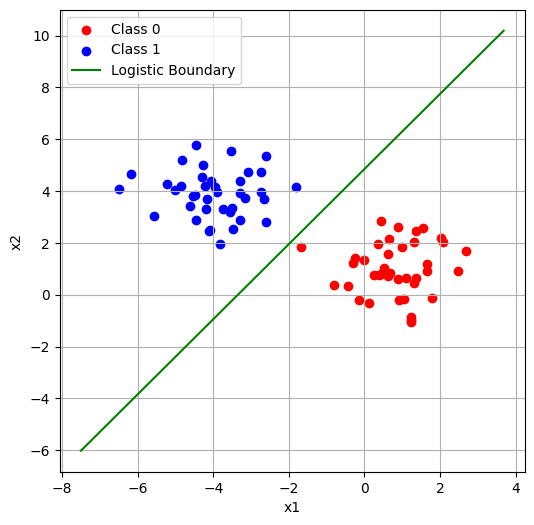

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(class0[:,0], class0[:,1], color='red', label='Class 0')
plt.scatter(class1[:,0], class1[:,1], color='blue', label='Class 1')
plt.plot(x_vals, y_vals_lr, 'g-', label='Logistic Boundary')
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()
